Saving house_price_regression_dataset.csv to house_price_regression_dataset (4).csv
'house_price_regression_dataset (4).csv' başarıyla yüklendi. Veri boyutu: (1000, 8)

--- MODEL PERFORMANSLARI ---
        Model      MAE     RMSE  MAPE(%)     R²  Adj_R²
      XGBoost 21170.47 26054.77     4.35 0.9895  0.9891
Decision Tree 29414.36 36108.94     6.10 0.9798  0.9791
Random Forest 22038.13 27168.56     4.57 0.9885  0.9882


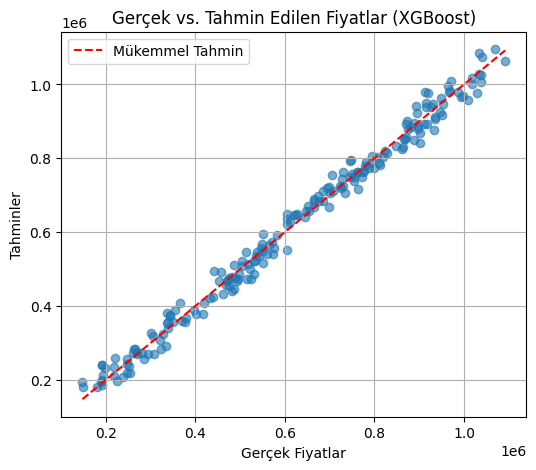

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"'{file_name}' başarıyla yüklendi. Veri boyutu: {df.shape}")

HEDEF = 'House_Price'
OZELIKLER = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms',
              'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']

X, y = df[OZELIKLER], df[HEDEF]
KATEGORIK = ['Neighborhood_Quality']
SAYISAL = [c for c in OZELIKLER if c not in KATEGORIK]

on_islemci = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='mean'))]), SAYISAL),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), KATEGORIK)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modeller = {
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}


sonuclar = []
for ad, model in modeller.items():
    pipe = Pipeline([('pre', on_islemci), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - len(OZELIKLER) - 1)

    sonuclar.append([ad, round(mae,2), round(rmse,2), round(mape,2), round(r2,4), round(adj_r2,4)])


sonuc_df = pd.DataFrame(sonuclar, columns=['Model','MAE','RMSE','MAPE(%)','R²','Adj_R²'])
print("\n--- MODEL PERFORMANSLARI ---")
print(sonuc_df.to_string(index=False))

plt.figure(figsize=(6,5))
xgb_pipe = Pipeline([('pre', on_islemci), ('model', modeller["XGBoost"])])
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Mükemmel Tahmin')
plt.title("Gerçek vs. Tahmin Edilen Fiyatlar (XGBoost)")
plt.xlabel("Gerçek Fiyatlar")
plt.ylabel("Tahminler")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
overfit_sonuclar = []

for ad, model in modeller.items():
    pipe = Pipeline([('pre', on_islemci), ('model', model)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    overfit_sonuclar.append([ad, round(r2_train,4), round(rmse_train,2), round(r2_test,4), round(rmse_test,2)])

overfit_df = pd.DataFrame(overfit_sonuclar, columns=['Model','R² Train','RMSE Train','R² Test','RMSE Test'])
print("\n--- EĞİTİM vs TEST PERFORMANSI ---")
print(overfit_df.to_string(index=False))



--- EĞİTİM vs TEST PERFORMANSI ---
        Model  R² Train  RMSE Train  R² Test  RMSE Test
      XGBoost    0.9997     4323.98   0.9895   26054.77
Decision Tree    1.0000        0.00   0.9798   36108.94
Random Forest    0.9982    10806.28   0.9885   27168.56


In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"'{file_name}' başarıyla yüklendi. Veri boyutu: {df.shape}")

HEDEF = 'House_Price'
OZELIKLER = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms',
             'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']

X, y = df[OZELIKLER], df[HEDEF]
KATEGORIK = ['Neighborhood_Quality']
SAYISAL = [c for c in OZELIKLER if c not in KATEGORIK]

on_islemci = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='mean'))]), SAYISAL),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), KATEGORIK)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modeller = {
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                            reg_alpha=0.1, reg_lambda=1, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=7, min_samples_leaf=5,
                                           random_state=42, n_jobs=-1)
}

sonuclar = []
for ad, model in modeller.items():
    pipe = Pipeline([('pre', on_islemci), ('model', model)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    sonuclar.append([ad, round(r2_train,4), round(rmse_train,2), round(r2_test,4), round(rmse_test,2)])

sonuc_df = pd.DataFrame(sonuclar, columns=['Model','R² Train','RMSE Train','R² Test','RMSE Test'])
print("\n--- EĞİTİM vs TEST PERFORMANSI (OVERFITTING AZALTILDI) ---")
print(sonuc_df.to_string(index=False))


Saving house_price_regression_dataset.csv to house_price_regression_dataset (5).csv
'house_price_regression_dataset (5).csv' başarıyla yüklendi. Veri boyutu: (1000, 8)

--- EĞİTİM vs TEST PERFORMANSI (OVERFITTING AZALTILDI) ---
        Model  R² Train  RMSE Train  R² Test  RMSE Test
      XGBoost    0.9979    11644.52   0.9900   25383.87
Decision Tree    0.9870    28916.71   0.9805   35417.73
Random Forest    0.9934    20641.43   0.9886   27056.98


In [ ]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print(f"'{file_name}' başarıyla yüklendi. Veri boyutu: {df.shape}")

HEDEF = 'House_Price'
OZELIKLER = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms',
             'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']

X, y = df[OZELIKLER], df[HEDEF]
KATEGORIK = ['Neighborhood_Quality']
SAYISAL = [c for c in OZELIKLER if c not in KATEGORIK]

on_islemci = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='mean'))]), SAYISAL),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), KATEGORIK)
])

modeller = {
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                            reg_alpha=0.1, reg_lambda=1, subsample=0.7, colsample_bytree=0.7,
                            random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=6, min_samples_leaf=5,
                                           random_state=42, n_jobs=-1)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
sonuclar = []

for ad, model in modeller.items():
    pipe = Pipeline([('pre', on_islemci), ('model', model)])

    r2_scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2', n_jobs=-1)

    from sklearn.metrics import make_scorer, mean_squared_error
    def rmse_scorer(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    rmse_scores = cross_val_score(pipe, X, y, cv=cv, scoring=make_scorer(rmse_scorer, greater_is_better=False), n_jobs=-1)

    sonuclar.append([ad, round(np.mean(r2_scores),4), round(np.std(r2_scores),4),
                     round(-np.mean(rmse_scores),2), round(np.std(rmse_scores),2)])

cv_df = pd.DataFrame(sonuclar, columns=['Model','R² Mean','R² Std','RMSE Mean','RMSE Std'])
print("\n--- CROSS-VALIDATION PERFORMANSI ---")
print(cv_df.to_string(index=False))


Saving house_price_regression_dataset.csv to house_price_regression_dataset (6).csv
'house_price_regression_dataset (6).csv' başarıyla yüklendi. Veri boyutu: (1000, 8)

--- CROSS-VALIDATION PERFORMANSI ---
        Model  R² Mean  R² Std  RMSE Mean  RMSE Std
      XGBoost   0.9892  0.0013   26225.11   1320.61
Decision Tree   0.9804  0.0022   35348.44   1546.89
Random Forest   0.9869  0.0017   28864.56   1608.11
